## Linear Regression — Experience vs Salary
Manual calculation, scikit-learn version, evaluation metrics (MSE, RMSE, R2), and scatter plot with best-fit line.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
data = {
    'Experience': [1, 2, 3, 4, 5, 6, 7],
    'Salary': [35, 40, 48, 55, 62, 68, 78]
}

In [13]:
df = pd.DataFrame(data)

In [14]:
df.head()

,Experience,Salary
0,1,35
1,2,40
2,3,48
3,4,55
4,5,62


In [16]:
X_MEAN = df['Experience'].mean()
y_MEAN = df['Salary'].mean()

In [18]:
df['X_DEV'] = df['Experience'] - X_MEAN
df['y_DEV'] = df['Salary'] - y_MEAN

In [20]:
df['XY_DEV'] = df['X_DEV'] * df['y_DEV']
df['X_DEV_SQ'] = df['X_DEV'] ** 2

In [21]:
b1 =  df['XY_DEV'].sum()/df['X_DEV_SQ'].sum()
b0 =  y_MEAN - b1 * X_MEAN

In [26]:
df['Predicted'] = b0 + b1 * df['Experience']
print(df[['Experience', 'Salary', 'Predicted']])
new_Exp = 8
prediction = b0 + b1 * new_Exp
print(f"Predicted score for {new_Exp} hours: {prediction}")

   Experience  Salary  Predicted
0           1      35  33.821429
1           2      40  40.928571
2           3      48  48.035714
3           4      55  55.142857
4           5      62  62.250000
5           6      68  69.357143
6           7      78  76.464286
Predicted score for 8 hours: 83.57142857142857


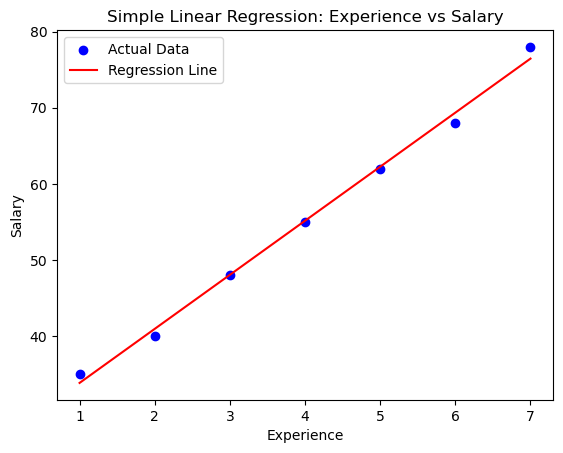

In [25]:
plt.scatter(df['Experience'], df['Salary'], color='blue', label='Actual Data')
plt.plot(df['Experience'], df['Predicted'], color='red', label='Regression Line')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.title('Simple Linear Regression: Experience vs Salary')
plt.legend()
plt.show()

In [28]:
df['Error'] = df['Salary'] - df['Predicted']
df['AbsError'] = df['Error'].abs()
df['SqError'] = df['Error'] ** 2
print("\nErrors:")
print(df[['Experience', 'Salary', 'Predicted', 'Error', 'AbsError', 'SqError']])

mae = df['AbsError'].mean()
mse = df['SqError'].mean()
rmse = mse ** 0.5

ss_res = df['SqError'].sum()
ss_tot = ((df['Salary'] - y_mean) ** 2).sum()
r2 = 1 - (ss_res / ss_tot)

print("\n--- Evaluation Metrics ---")
print(f"MAE  (Mean Absolute Error):     {mae:.4f}")
print(f"MSE  (Mean Squared Error):      {mse:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")


Errors:
   Experience  Salary  Predicted     Error  AbsError   SqError
0           1      35  33.821429  1.178571  1.178571  1.389031
1           2      40  40.928571 -0.928571  0.928571  0.862245
2           3      48  48.035714 -0.035714  0.035714  0.001276
3           4      55  55.142857 -0.142857  0.142857  0.020408
4           5      62  62.250000 -0.250000  0.250000  0.062500
5           6      68  69.357143 -1.357143  1.357143  1.841837
6           7      78  76.464286  1.535714  1.535714  2.358418

--- Evaluation Metrics ---
MAE  (Mean Absolute Error):     0.7755
MSE  (Mean Squared Error):      0.9337
RMSE (Root Mean Squared Error): 0.9663


In [29]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data
data = {
    'Experience': [1, 2, 3, 4, 5, 6, 7],
    'Salary': [35, 40, 48, 55, 62, 68, 78]
}
df = pd.DataFrame(data)
print("Original Data:")
print(df)

# X must be 2D (DataFrame), Y can be 1D (Series)
X = df[['Experience']]
Y = df['Salary']

# Fit
model = LinearRegression()
model.fit(X, Y)

b1 = model.coef_[0]
b0 = model.intercept_
print(f"\nSlope (b1): {b1:.4f}")
print(f"Intercept (b0): {b0:.4f}")

# Predict
df['Predicted'] = model.predict(X)
print(df[['Experience', 'Salary', 'Predicted']])

# Metrics
mae = mean_absolute_error(Y, df['Predicted'])
mse = mean_squared_error(Y, df['Predicted'])
rmse = mse ** 0.5
r2 = r2_score(Y, df['Predicted'])
print(f"MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

# Predict new value
new_pred = model.predict(pd.DataFrame({'Experience': [8]}))
print(f"Predicted salary for 8 years: {new_pred[0]:.2f}")

Original Data:
   Experience  Salary
0           1      35
1           2      40
2           3      48
3           4      55
4           5      62
5           6      68
6           7      78

Slope (b1): 7.1071
Intercept (b0): 26.7143
   Experience  Salary  Predicted
0           1      35  33.821429
1           2      40  40.928571
2           3      48  48.035714
3           4      55  55.142857
4           5      62  62.250000
5           6      68  69.357143
6           7      78  76.464286
MAE: 0.7755 | MSE: 0.9337 | RMSE: 0.9663 | R²: 0.9954
Predicted salary for 8 years: 83.57
